In [25]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')


Model is ready


In [ ]:
from langchain_community.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather for a city"""
    return f"The weather in the city {city} is Sunny"

@tool
def get_stock_price(stock: str) -> str:
    """Returns the stock price for a given stock"""
    return f"The stock price of {stock} is 25.50"

ALL_TOOLS = [get_weather, get_stock_price]
print('Mode with Tools are ready')

Mode with Tools are ready


In [27]:
# STEP 1 - Define the central state of the application
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print('Graph State is ready')


Graph State is ready


In [48]:
# STEP 2 - Define your nodes

llm_with_tools = model.bind_tools(ALL_TOOLS)

def assistant(state:AgentState) -> dict:
    """Assistant node: call the model, allowing it to request tools."""
    response = llm_with_tools.invoke(state['messages'])
    return {"messages": [response]}

def route_after_assistant(state:AgentState) -> str:
    """Route to tools only when model produces tool calls"""
    last_message = state['messages'][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END
print('Nodes are ready')

Nodes are ready


In [49]:
# STEP 3 - Bind nodes together using Edges
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

tools_graph_builder = StateGraph(AgentState)

# Node registration
tools_graph_builder.add_node("assistant", assistant)
tools_graph_builder.add_node("tools", ToolNode(ALL_TOOLS))

# Add edges to nodes
tools_graph_builder.add_edge(START, "assistant")
tools_graph_builder.add_conditional_edges(
    "assistant",
    route_after_assistant,
    {
        "tools": "tools",
        END: END
    }
)
tools_graph_builder.add_edge("tools", "assistant")

tool_graph = tools_graph_builder.compile()
print('Tool graph is ready')

Tool graph is ready


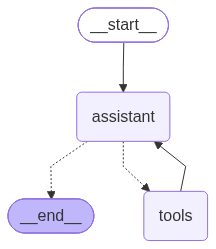

In [50]:
tool_graph

In [51]:
response = tool_graph.invoke({
    "messages": [
        {"role": "user", "content": "How is the weather in Pune city today?"}
    ]
})

response

{'messages': [HumanMessage(content='How is the weather in Pune city today?', additional_kwargs={}, response_metadata={}, id='a5b17f19-6619-4e4d-a51f-8c012fdf6264'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-17T05:51:19.620643071Z', 'done': True, 'done_reason': 'stop', 'total_duration': 397134293, 'load_duration': None, 'prompt_eval_count': 155, 'prompt_eval_duration': None, 'eval_count': 44, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0adeb-5d7e-7041-9e7a-24332d1e7d2c-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Pune'}, 'id': 'fa21d955-7030-46e8-ac8b-cc062ed25633', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 155, 'output_tokens': 44, 'total_tokens': 199}),
  ToolMessage(content='The weather in the city Pune is Sunny', name='get_weather', id='847eb2f6-5e8a-4533-836e-b6f8af1d8e01', tool_call_id='fa21d9